In [31]:
!pip install -q ucimlrepo

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [33]:
data = {
    "Age": [22, 25, 28, 30, 32, 35, 38, 40, 42, 45,
            24, 27, 31, 34, 37, 41, 44, 29, 33, 39],

    "Experience": [0, 2, 4, 6, 8, 10, 12, 15, 18, 20,
                   1, 3, 7, 9, 11, 14, 17, 5, 8, 13],

    "Education": [
        "Bachelor", "Bachelor", "Bachelor", "Master", "Master",
        "Master", "Master", "PhD", "PhD", "PhD",
        "Bachelor", "Bachelor", "Master", "Master", "Master",
        "PhD", "PhD", "Bachelor", "Master", "PhD"
    ],

    "Salary": [
        30000, 35000, 40000, 48000, 55000,
        62000, 70000, 85000, 100000, 115000,
        32000, 38000, 50000, 58000, 68000,
        82000, 98000, 43000, 60000, 90000
    ]
}

In [34]:
df = pd.DataFrame(data)
df

,Age,Experience,Education,Salary
0,22,0,Bachelor,30000
1,25,2,Bachelor,35000
2,28,4,Bachelor,40000
3,30,6,Master,48000
4,32,8,Master,55000
5,35,10,Master,62000
6,38,12,Master,70000
7,40,15,PhD,85000
8,42,18,PhD,100000
9,45,20,PhD,115000


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Age         20 non-null     int64 
 1   Experience  20 non-null     int64 
 2   Education   20 non-null     object
 3   Salary      20 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 772.0+ bytes


The dataset has 20 rows and 4 columns with no missing values.


In [36]:
df.head()

,Age,Experience,Education,Salary
0,22,0,Bachelor,30000
1,25,2,Bachelor,35000
2,28,4,Bachelor,40000
3,30,6,Master,48000
4,32,8,Master,55000


In [37]:
df.describe()

,Age,Experience,Salary
count,20.000000,20.000000,20.000000
mean,33.800000,9.150000,62950.000000
std,6.825648,5.815361,24949.369784
min,22.000000,0.000000,30000.000000
25%,28.750000,4.750000,42250.000000
50%,33.500000,8.500000,59000.000000
75%,39.250000,13.250000,82750.000000
max,45.000000,20.000000,115000.000000


In [38]:
df.shape

(20, 4)

In [39]:
df.columns

Index(['Age', 'Experience', 'Education', 'Salary'], dtype='object')

In [40]:
df.columns.tolist()

['Age', 'Experience', 'Education', 'Salary']

In [41]:
df.dtypes

,0
Age,int64
Experience,int64
Education,object
Salary,int64


In [42]:
df.isnull().sum()

,0
Age,0
Experience,0
Education,0
Salary,0


In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df = df.drop_duplicates()
df

,Age,Experience,Education,Salary
0,22,0,Bachelor,30000
1,25,2,Bachelor,35000
2,28,4,Bachelor,40000
3,30,6,Master,48000
4,32,8,Master,55000
5,35,10,Master,62000
6,38,12,Master,70000
7,40,15,PhD,85000
8,42,18,PhD,100000
9,45,20,PhD,115000


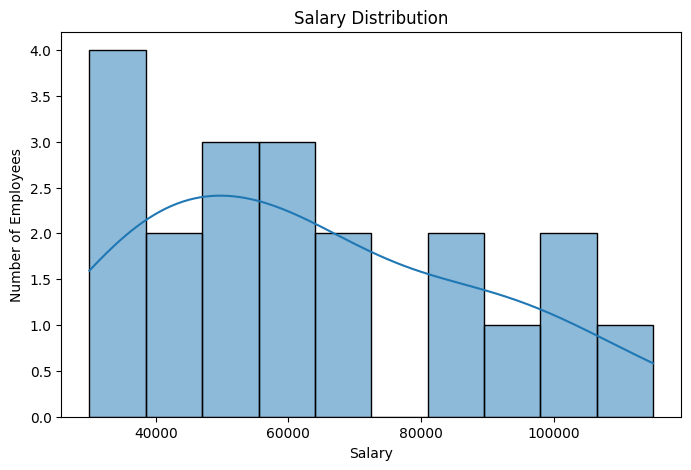

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary"], bins=10, kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()

Most salaries are between 30,000 and 70,000, while fewer employees have very high salaries above 80,000.


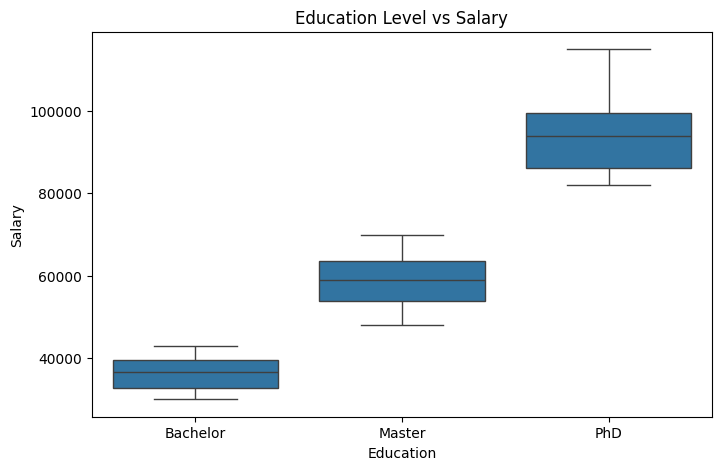

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Education",y="Salary",data=df)
plt.title("Education Level vs Salary")
plt.show()

Higher education is linked to higher salary.


In [47]:
df = df[
    (df["Age"] > 0) &
    (df["Experience"] >= 0) &
    (df["Salary"] > 0)
]
df

,Age,Experience,Education,Salary
0,22,0,Bachelor,30000
1,25,2,Bachelor,35000
2,28,4,Bachelor,40000
3,30,6,Master,48000
4,32,8,Master,55000
5,35,10,Master,62000
6,38,12,Master,70000
7,40,15,PhD,85000
8,42,18,PhD,100000
9,45,20,PhD,115000


In [48]:
def experience_group(x):

    if x <= 2:
        return "Beginner"

    elif x <= 5:
        return "Junior"

    elif x <= 10:
        return "Mid-Level"

    else:
        return "Senior"

df["Experience_Group"] = df["Experience"].apply(experience_group)



In [49]:
X = df[["Age","Experience","Education","Experience_Group"]]
y = df["Salary"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (16, 4)
Testing: (4, 4)


In [51]:
numeric_features = ["Age","Experience"]
categorical_features = ["Education","Experience_Group"]


In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),

        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [53]:
linear_model = Pipeline(
    steps=[ ("preprocessor", preprocessor),("model", LinearRegression())]
    )

linear_model.fit(X_train,y_train)
linear_pred = linear_model.predict(X_test)

In [54]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_test)

In [55]:
models = {
    "Linear Regression": linear_pred,
    "Random Forest": rf_pred
}

results = []

for name, prediction in models.items():
    mae = mean_absolute_error( y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score( y_test,prediction)

    results.append([name,mae,rmse,r2])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3339.165733,4369.918648,0.954343
1,Random Forest,3252.500000,4005.936220,0.961632


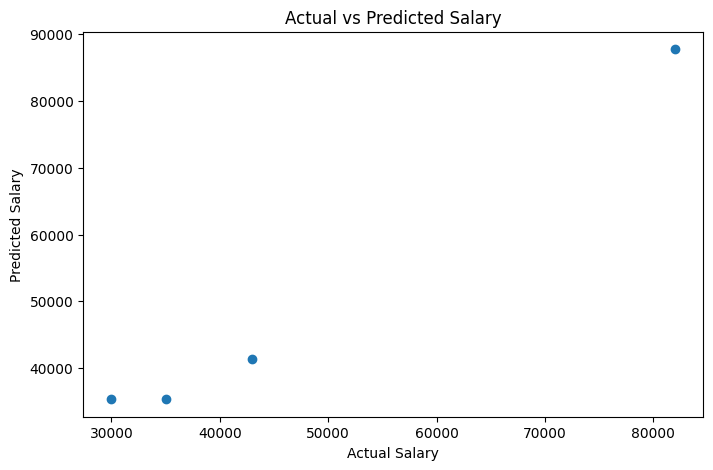

In [56]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,rf_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

The predicted salaries are close to the actual salaries, showing that the model is making reasonable predictions.


In [57]:
scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(scores)

print("Average R2 Score:", scores.mean())

Cross Validation Scores:
[0.88140594 0.84746908 0.89428967 0.95844746 0.92397377]
Average R2 Score: 0.9011171850060453


In [58]:
joblib.dump(rf_model, "salary_prediction_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [59]:
loaded_model = joblib.load( "salary_prediction_model.pkl")
print("Model loaded successfully!")

Model loaded successfully!
